**MÅLTE 60 BPM RETT ETTER VIDEO-OPPTAK**

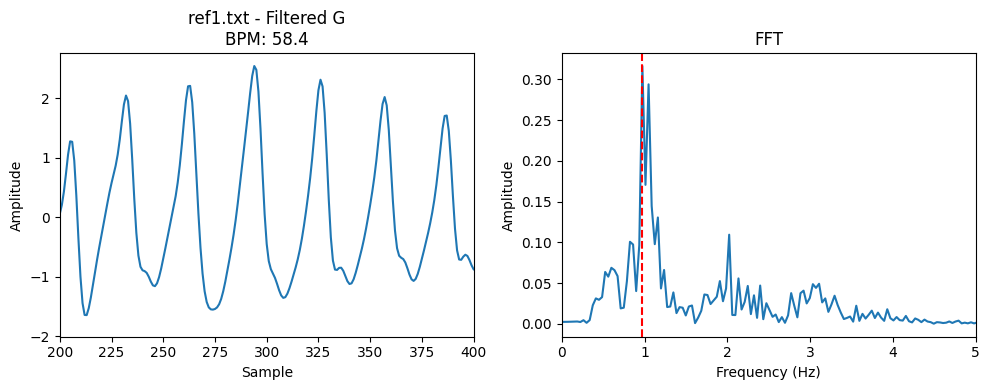

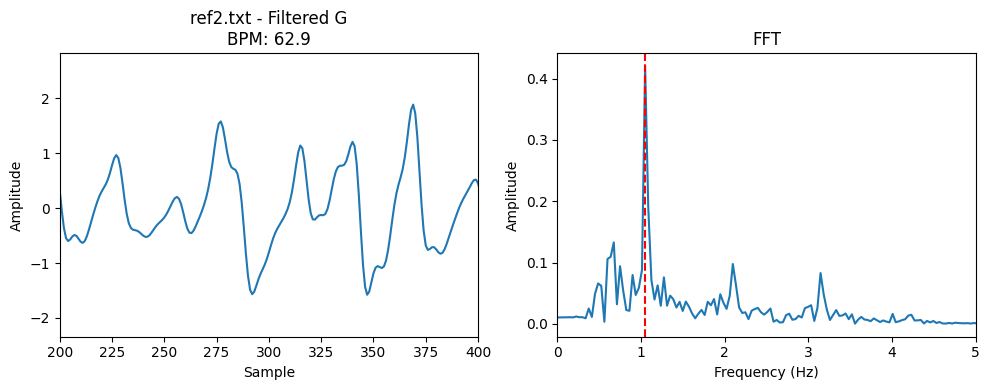

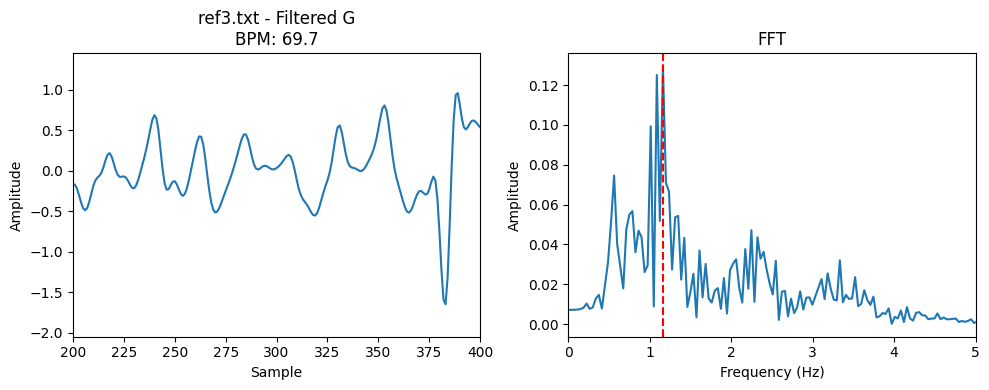

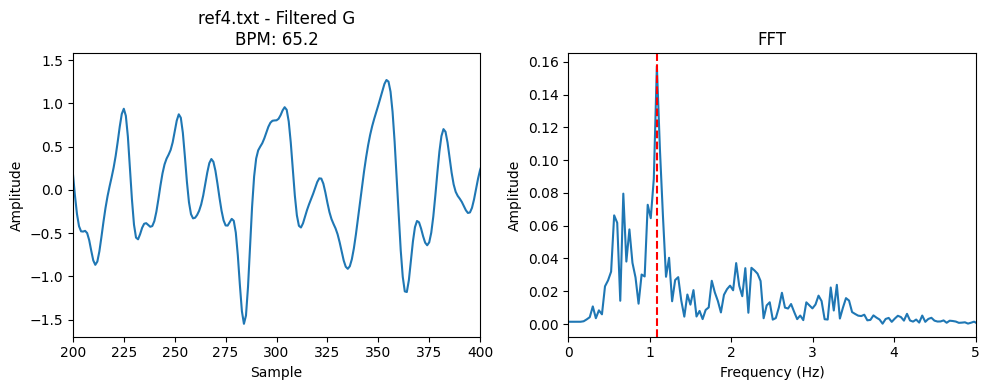

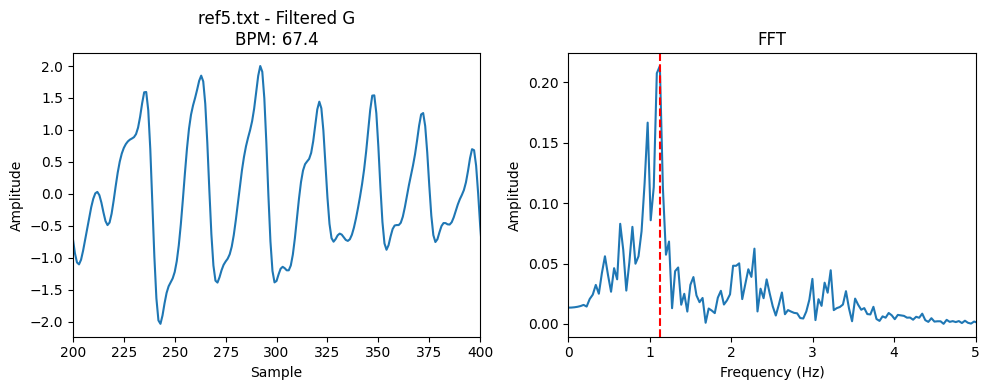

Mean BPM: 64.71910112359551
Std BPM: 3.8662136031652223


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

fs = 30
lowcut = 0.5
highcut = 4

files = ["ref1.txt",
         "ref2.txt",
         "ref3.txt",
         "ref4.txt",
         "ref5.txt"]

b, a = butter(3, [lowcut/(fs/2), highcut/(fs/2)], btype='band')
bpms = []


for filename in files:

    data = np.loadtxt(filename)
    G = data[:,1]

    G_ac = G - np.mean(G)
    G_ac = G_ac[3*fs:]
    G_filt = filtfilt(b, a, G_ac)

    N = len(G_filt)
    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(G_filt)) / N

    mask = (freqs >= 0.5) & (freqs <= 4)
    freqs_band = freqs[mask]
    fft_band = fft_vals[mask]

    peak_freq = freqs_band[np.argmax(fft_band)]
    bpm = peak_freq * 60
    bpms.append(bpm)


    plt.figure(figsize=(10,4))


    plt.subplot(1,2,1)
    plt.plot(G_filt)
    plt.title(f"{filename} - Filtered G\nBPM: {bpm:.1f}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.xlim(200,400)

    
    plt.subplot(1,2,2)
    plt.plot(freqs, fft_vals)
    plt.xlim(0,5)
    plt.axvline(peak_freq, color='r', linestyle='--')
    plt.title("FFT")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")

    plt.tight_layout()
    plt.show()

print("Mean BPM:", np.mean(bpms))
print("Std BPM:", np.std(bpms))


Får høyere STD på reflektans enn transmittans. Gjennomsnittsverdien er og lengre unna målt verdi.

R BPM: 62.921348314606746
G BPM: 58.426966292134836
B BPM: 60.67415730337079


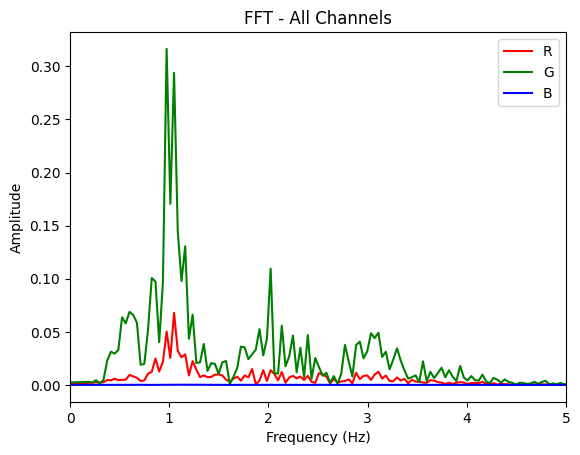

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

fs = 30
lowcut = 0.5
highcut = 4

filename = "ref1.txt"
data = np.loadtxt(filename)

R = data[:,0]
G = data[:,1]
B = data[:,2]

cut = 3 * fs
R = R[cut:]
G = G[cut:]
B = B[cut:]

R_ac = R - np.mean(R)
G_ac = G - np.mean(G)
B_ac = B - np.mean(B)

b, a = butter(3, [lowcut/(fs/2), highcut/(fs/2)], btype='band')

R_f = filtfilt(b, a, R_ac)
G_f = filtfilt(b, a, G_ac)
B_f = filtfilt(b, a, B_ac)


def compute_fft(signal):
    N = len(signal)
    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(signal)) / N
    return freqs, fft_vals

freqs, R_fft = compute_fft(R_f)
_, G_fft = compute_fft(G_f)
_, B_fft = compute_fft(B_f)


mask = (freqs >= 0.5) & (freqs <= 4)

def find_bpm(fft_vals):
    freqs_band = freqs[mask]
    fft_band = fft_vals[mask]
    peak_freq = freqs_band[np.argmax(fft_band)]
    return peak_freq * 60

print("R BPM:", find_bpm(R_fft))
print("G BPM:", find_bpm(G_fft))
print("B BPM:", find_bpm(B_fft))


plt.figure()
plt.plot(freqs, R_fft, label="R", color='r')
plt.plot(freqs, G_fft, label="G", color='g')
plt.plot(freqs, B_fft, label="B", color='b')
plt.xlim(0,5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("FFT - All Channels")
plt.show()


In [6]:
def compute_snr(signal, fs):

    N = len(signal)

    freqs = np.fft.rfftfreq(N, 1/fs)
    fft_vals = np.abs(np.fft.rfft(signal)) / N

    
    mask = (freqs >= 0.5) & (freqs <= 4)

    freqs_band = freqs[mask]
    fft_band = fft_vals[mask]

    
    peak_idx = np.argmax(fft_band)
    peak_freq = freqs_band[peak_idx]
    peak_amp = fft_band[peak_idx]

    
    exclude = 0.1
    noise_mask = np.abs(freqs_band - peak_freq) > exclude
    noise_vals = fft_band[noise_mask]

    noise_mean = np.mean(noise_vals)

    snr_linear = peak_amp / noise_mean
    snr_db = 20 * np.log10(snr_linear)

    bpm = peak_freq * 60

    return bpm, snr_linear, snr_db

bpm_R, snr_R, snr_R_db = compute_snr(R_f, fs)
bpm_G, snr_G, snr_G_db = compute_snr(G_f, fs)
bpm_B, snr_B, snr_B_db = compute_snr(B_f, fs)

print("R: BPM =", f"{bpm_R:.1f}", "SNR =", f"{snr_R_db:.1f}", "dB")
print("G: BPM =", f"{bpm_G:.1f}", "SNR =", f"{snr_G_db:.1f}", "dB")
print("B: BPM =", f"{bpm_B:.1f}", "SNR =", f"{snr_B_db:.1f}", "dB")


R: BPM = 62.9 SNR = 19.7 dB
G: BPM = 58.4 SNR = 20.2 dB
B: BPM = 60.7 SNR = 13.8 dB
